In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from planetmagfields import Planet
from inversemodel import InverseModel
from tqdm import tqdm

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = True
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

## Read data

In [2]:
df = pd.read_csv('./pds_data/uranus48s.csv')

theta = df['Colatitude'] * np.pi / 180
phi = (df['Longitude'] % 360) * np.pi / 180
r = df['Radius'].values

## Inverse Modeling

## Find optimal $\alpha$

  0%|                                                                                                                                                                                                         | 0/50 [00:00<?, ?it/s]

 20%|██████████████████████████████████████▍                                                                                                                                                         | 10/50 [00:00<00:00, 94.53it/s]

 52%|███████████████████████████████████████████████████████████████████████████████████████████████████▎                                                                                           | 26/50 [00:00<00:00, 130.59it/s]

 80%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                      | 40/50 [00:00<00:00, 122.35it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 122.49it/s]

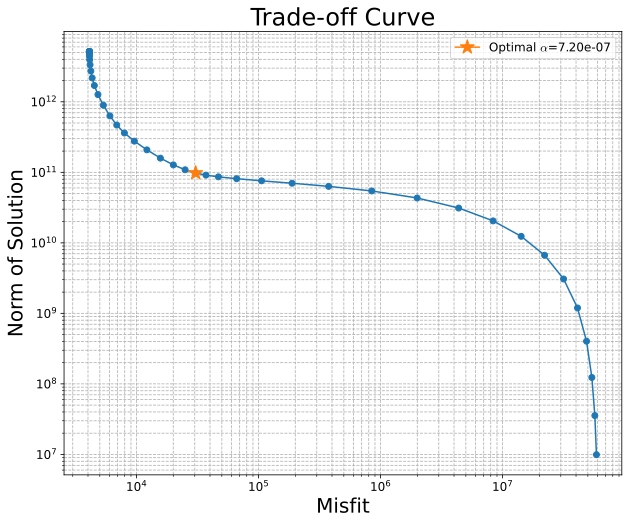

In [3]:
# # Create model
M = InverseModel(lmax=3, r=r, theta=theta, phi=phi,
                 br=df['Br'].values,
                 btheta=df['Btheta'].values,
                 bphi=df['Bphi'].values,
                 smoothing_norm='ohmic',
                 include_external=True,
                 a=1,b=0.8,c=0.7)

# Define alpha range
alpha_arr = np.logspace(-15, -1, 50)


# Plot trade-off curve
misfit_arr = []
norm_arr = []
for alpha in tqdm(alpha_arr):
    M.solve(alpha=alpha)
    misfit_arr.append(M.misfit)
    norm_arr.append(M.norm_value)

# Find optimal alpha (e.g., using L-curve corner)
# We find max curvature point on log-log trade-off curve
log_misfit = np.log(misfit_arr)
log_norm = np.log(norm_arr)
d_log_misfit = np.gradient(log_misfit)
d_log_norm = np.gradient(log_norm)
d2_log_misfit = np.gradient(d_log_misfit)
d2_log_norm = np.gradient(d_log_norm)
curvature = np.abs(d_log_misfit * d2_log_norm - d_log_norm * d2_log_misfit) / (d_log_misfit**2 + d_log_norm**2)**1.5
optimal_idx = np.argmax(curvature)
optimal_alpha = alpha_arr[optimal_idx]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))
ax.loglog(misfit_arr, norm_arr, marker='o')
ax.loglog(misfit_arr[optimal_idx], norm_arr[optimal_idx], marker='*', markersize=15, label=r'Optimal $\alpha$=%.2e' % optimal_alpha)
ax.legend()
ax.set_xlabel('Misfit')
ax.set_ylabel('Norm of Solution')
ax.set_title('Trade-off Curve')
ax.grid(True, which='both', ls='--')
if savefigs:
    plt.savefig('figures/tradeoff_curve.png', dpi=300, bbox_inches='tight')
plt.show()

M.solve(alpha=optimal_alpha)

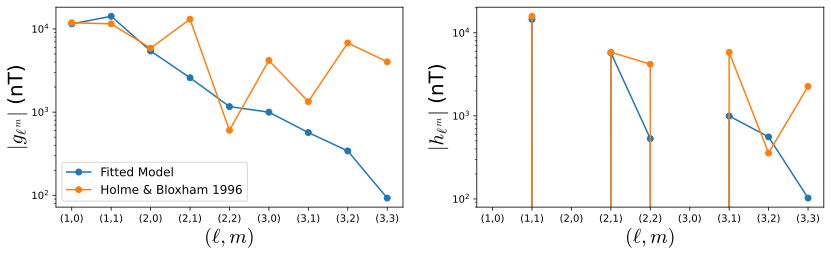

In [4]:
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
for i in [0,1]:
    if i == 0:
        coeff = M.glm[:9]
        coeff_ref = pl.glm[1:10]
        ylabel = r'$|g_{\ell^m}|$ (nT)'
    if i == 1:
        coeff = M.hlm[:9]
        coeff_ref = pl.hlm[1:10]
        ylabel = r'$|h_{\ell^m}|$ (nT)'

    ax[i].plot(np.abs(coeff),'-o',label='Fitted Model')
    ax[i].plot(np.abs(coeff_ref),'-o',label='Holme & Bloxham 1996')
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$(\ell,m)$',fontsize=20)
    ax[i].set_xticks(np.arange(9))
    ax[i].set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].set_ylabel(ylabel,fontsize=20)

ax[0].legend()
fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_fitted_gauss_coefficients.png', dpi=300)
plt.show()

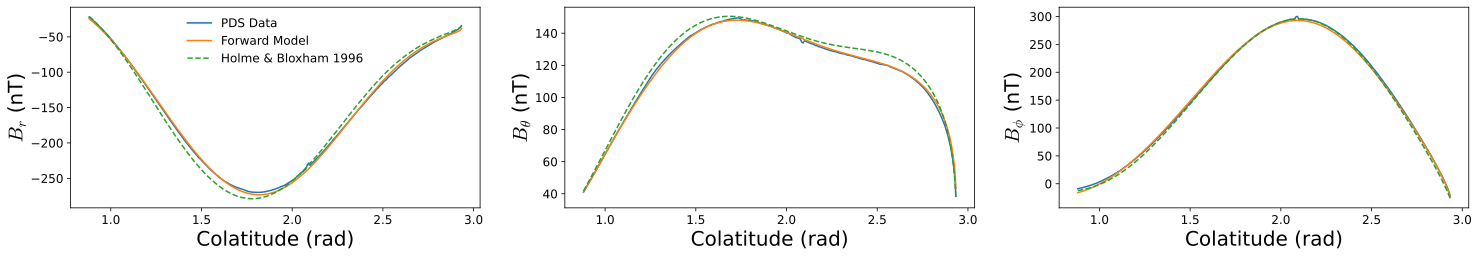

In [5]:
#Test both forward models:

b = np.real(M.A @ M.coeffs)
br = b[0::3]
btheta = b[1::3]
bphi = b[2::3]

# Rearrange Holme and Bloxham 1996 coefficients into same format as M.coeffs
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
coeffs_hb = np.zeros(M.ncoeffs)

for l in range(1, min(M.lmax,pl.lmax) + 1):
    for m in range(l + 1):
        # Get coefficient from pl using pl's indexing
        coeffs_hb[M.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

        if m > 0:
            coeffs_hb[M.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

# Forward model
b_hb = M.A @ coeffs_hb
br_hb = b_hb[0::3]
btheta_hb = b_hb[1::3]
bphi_hb = b_hb[2::3]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(21, 4), sharex=True)
ax[0].plot(theta, df['Br'], label='PDS Data')
ax[0].plot(theta, br, label='Forward Model')
ax[0].plot(theta, br_hb, label='Holme & Bloxham 1996', linestyle='--')
ax[0].set_ylabel(r'$B_r$ (nT)')
ax[0].set_xlabel('Colatitude (rad)')
ax[0].legend(frameon=False)
ax[1].plot(theta, df['Btheta'])
ax[1].plot(theta, btheta)
ax[1].plot(theta, btheta_hb, linestyle='--')
ax[1].set_ylabel(r'$B_\theta$ (nT)')
ax[1].set_xlabel('Colatitude (rad)')
ax[2].plot(theta, df['Bphi'])
ax[2].plot(theta, bphi)
ax[2].plot(theta, bphi_hb, linestyle='--')
ax[2].set_ylabel(r'$B_\phi$ (nT)')
ax[2].set_xlabel('Colatitude (rad)')
fig.tight_layout()

if savefigs:
    plt.savefig('figures/uranus_forward_model.png', dpi=300)
plt.show()

In [6]:
# Print external coefficients:

print(f"External field coefficients:")
print(f"  G10 = {M.G10:.2f} nT")
print(f"  G11 = {M.G11:.2f} nT")
print(f"  H11 = {M.H11:.2f} nT")

External field coefficients:
  G10 = -2.85 nT
  G11 = -3.64 nT
  H11 = -10.41 nT


In [7]:
# Compare actual values
print("Model glm:", M.glm)
print("Holme & Bloxham glm:", pl.glm[1:])
print("Model hlm:", M.hlm)
print("Holme & Bloxham hlm:", pl.hlm[1:])

Model glm: [11509.62574678 14185.12649681 -5429.2193874  -2586.73589014
  1164.56132808   997.72153703  -567.34410146  -341.19958183
    92.68042071]
Holme & Bloxham glm: [ 11854.69  11507.23  -5877.08 -13084.9    -604.66   4182.82  -1335.73
  -6776.28  -4021.38]
Model hlm: [     0.         -14514.31815257      0.           5754.41769673
   -532.33206472      0.           -995.78152654   -558.27748424
    102.58967486]
Holme & Bloxham hlm: [     0.    -15811.9        0.      5850.66    4184.69       0.
  -5816.665   -357.27   -2265.15 ]


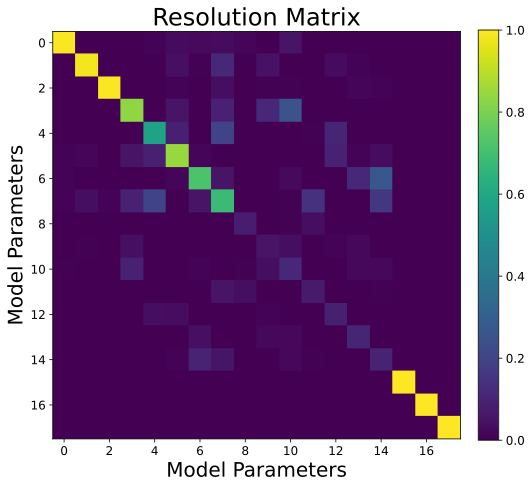

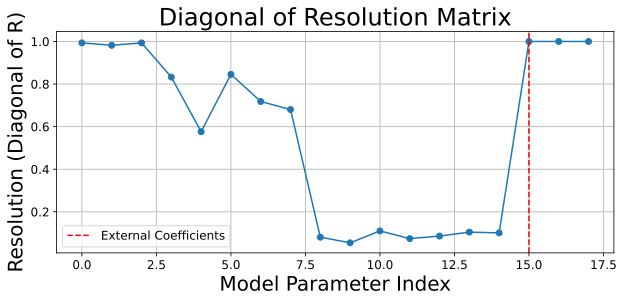

In [8]:
# Plot resolution matrix like Holme & Bloxham 1996
M.resolution_matrix(alpha=optimal_alpha)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
im = ax.imshow(M.R, cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('Model Parameters')
ax.set_ylabel('Model Parameters')
ax.set_title('Resolution Matrix')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
if savefigs:
    plt.savefig('figures/uranus_resolution_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Also show an unwrapped version of the resolution matrix to see the diagonal more clearly,
# Mark last three points as external field coefficients
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
ax.plot(np.diag(M.R), marker='o')
ax.axvline(M.ncoeffs-3, color='red', linestyle='--', label='External Coefficients')
ax.legend()
ax.set_xlabel('Model Parameter Index')
ax.set_ylabel('Resolution (Diagonal of R)')
ax.set_title('Diagonal of Resolution Matrix')
ax.grid()
if savefigs:
    plt.savefig('figures/uranus_resolution_matrix_diagonal.png', dpi=300, bbox_inches='tight')
plt.show()